## Baseline HAR Model

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

DATA_PATH = os.path.join('..', 'data', 'panel_data_model_ready.parquet')

df = pd.read_parquet(DATA_PATH)
print(f'Data Shape: {df.shape}')
display(df.head())

har_features = ['rv_lag_1', 'rv_rolling_5', 'rv_rolling_22']
Y = df['Y_reg']

har_extended_features = har_features + ['vix_lag_1', 'bpv_lag_1', 'rq_lag_1']
X_har = df[har_features]

X_advanced = df.drop(columns=['rv', 'bpv', 'good', 'bad', 'rq', 'vix', 'Y_reg'])

df_har = df.copy()
df_har = df.dropna(subset=['rv_lag_1','rv_rolling_5','rv_rolling_22','Y_reg']).copy()
df_har = df_har.sort_index(level=['Stock', 'Date'])

print(f'Target (Y) shape: {Y.shape}')
print(f'HAR Features (X_har) shape: {X_har.shape}')
print(f'Advanced Features (X_advanced) shape: {X_advanced.shape}')
display(X_har.head())
display(X_har.tail())

Data Shape: (153515, 17)


rv       bpv      good       bad         rq    vix  \
Date       Stock                                                             
2003-01-03 AAPL   6.574494  5.893317  3.638035  2.936459  62.054316  24.68   
           AMGN   3.225009  3.043199  1.961131  1.263879  31.538602  24.68   
           AMZN   5.290480  4.212468  3.812314  1.478167  61.555140  24.68   
           AXP    3.394580  3.409980  1.725383  1.669197  13.330858  24.68   
           BA     3.064001  3.755029  1.403990  1.660010  13.424943  24.68   

                     Y_reg  rv_lag_1  rv_rolling_5  rv_rolling_22  bpv_lag_1  \
Date       Stock                                                               
2003-01-03 AAPL   5.992264  6.493909      6.493909       6.493909   3.771960   
           AMGN   2.460476  5.177506      5.177506       5.177506   3.635898   
           AMZN   5.818162  9.886836      9.886836       9.886836   8.018926   
           AXP    4.693210  4.448244      4.448244       4.448244   4.122573   
           BA     2.934207  7.469396      7.469396       7.469396   7.016747   

                  good_lag_1  bad_lag_1    rq_lag_1  vix_lag_1  \
Date       Stock                                                 
2003-01-03 AAPL     5.102315   1.391595  152.729402      25.39   
           AMGN     3.362921   1.814585   46.168213      25.39   
           AMZN     6.074276   3.812559  200.751309      25.39   
           AXP      3.337253   1.110991  114.695371      25.39   
           BA       5.107386   2.362010  150.112379      25.39   

                  bad_good_ratio_lag_1  jump_ratio_lag_1  
Date       Stock                                          
2003-01-03 AAPL               0.272738          0.419154  
           AMGN               0.539586          0.297751  
           AMZN               0.627656          0.188929  
           AXP                0.332906          0.073213  
           BA                 0.462469          0.060600

Target (Y) shape: (153515,)
HAR Features (X_har) shape: (153515, 3)
Advanced Features (X_advanced) shape: (153515, 10)


rv_lag_1  rv_rolling_5  rv_rolling_22
Date       Stock                                       
2003-01-03 AAPL   6.493909      6.493909       6.493909
           AMGN   5.177506      5.177506       5.177506
           AMZN   9.886836      9.886836       9.886836
           AXP    4.448244      4.448244       4.448244
           BA     7.469396      7.469396       7.469396

rv_lag_1  rv_rolling_5  rv_rolling_22
Date       Stock                                       
2024-03-27 TRV    0.662026      0.509677       0.658727
           UNH    0.738759      0.577990       1.216626
           V      1.870995      0.907149       0.653616
           VZ     0.304812      0.675192       1.060689
           WMT    0.523779      0.504518       0.655106

## Rolling window

Initialized TimeSeriesSplit with 5 splits.


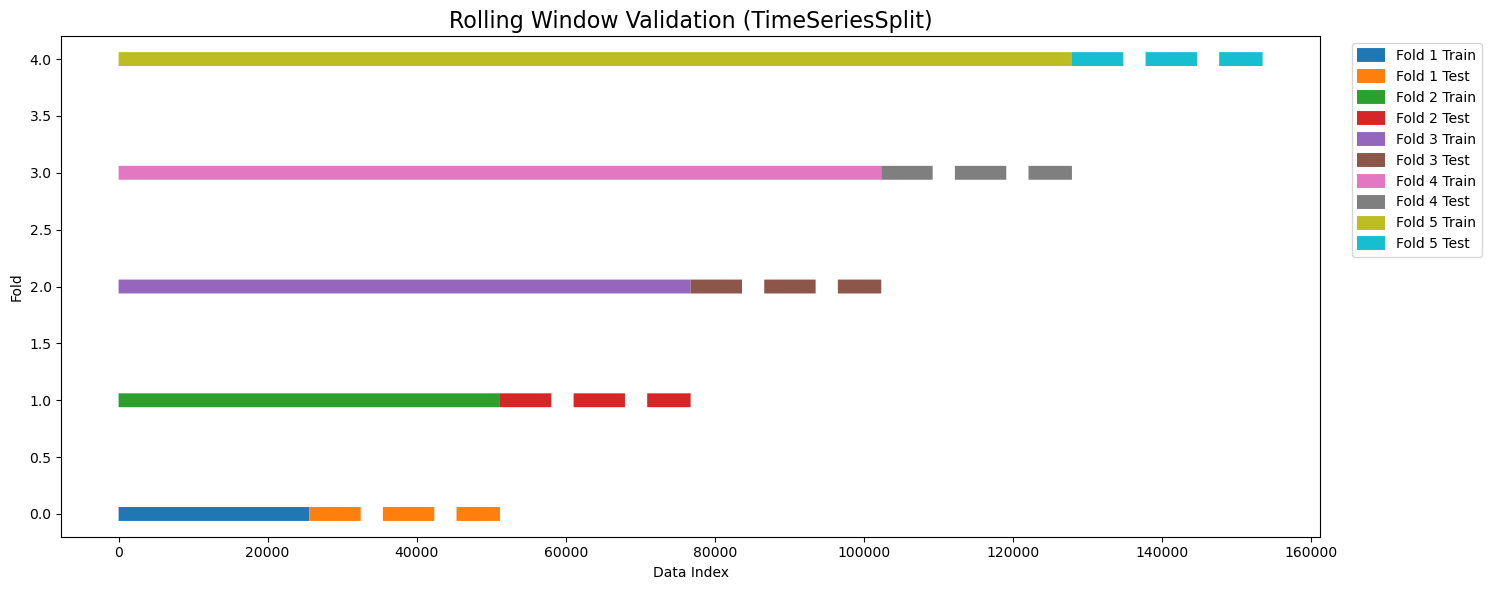

In [2]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print(f'Initialized TimeSeriesSplit with {N_SPLITS} splits.')

fig, ax = plt.subplots(figsize=(15, 6))
for i, (train_index, test_index) in enumerate(tscv.split(X_har)):
    ax.plot(train_index, [i] * len(train_index), label=f'Fold {i+1} Train', lw=10, solid_capstyle='butt')
    ax.plot(test_index, [i] * len(test_index), label=f'Fold {i+1} Test', lw=10, ls='--', solid_capstyle='butt')

ax.set_title('Rolling Window Validation (TimeSeriesSplit)', fontsize=16)
ax.set_xlabel('Data Index')
ax.set_ylabel('Fold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Train HAR model

In [3]:
# Method 1: using 80%-20% train-test split
split_date = '2020-01-01'
train = df_har.loc[df_har.index.get_level_values('Date') < split_date]
test  = df_har.loc[df_har.index.get_level_values('Date') >= split_date]

X_train = train[['rv_lag_1','rv_rolling_5','rv_rolling_22']]
y_train = train['Y_reg']
X_test  = test[['rv_lag_1','rv_rolling_5','rv_rolling_22']]
y_test  = test['Y_reg']

har_model_holdout = LinearRegression()
har_model_holdout.fit(X_train, y_train)

y_pred = har_model_holdout.predict(X_test)
test = test.copy()
test['har_pred'] = y_pred

mse = mean_squared_error(y_test, y_pred)
print(f"HAR Baseline Test MSE: {mse:.6f}")

df.loc[test.index, 'har_pred'] = y_pred
df['residual'] = df['Y_reg'] - df['har_pred']

mse_per_stock = (
    test.groupby('Stock')
        .apply(lambda g: mean_squared_error(g['Y_reg'], g['har_pred']))
        .sort_values()
)

print(f"average per-stock MSE: {mse_per_stock.mean():.6f}")
print(f"median per-stock MSE: {mse_per_stock.median():.6f}")

HAR Baseline Test MSE: 21.783349
average per-stock MSE: 21.783349
median per-stock MSE: 13.239796


In [4]:
# Method 2: rolling window folds split
har_mse_scores = []

print('Training & Evaluation for HAR...')

for i, (train_index, test_index) in enumerate(tscv.split(X_har)):
    print(f'--- Fold {i+1}/{N_SPLITS} ---')
    
    X_train, X_test = X_har.iloc[train_index], X_har.iloc[test_index]
    y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]
    
    print(f"  Train size: {len(X_train)}, Test size: {len(X_test)}")
    
    har_model_fold = LinearRegression()
    har_model_fold.fit(X_train, y_train)
    
    y_pred = har_model_fold.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    har_mse_scores.append(mse)
    
    print(f"  Fold {i+1} MSE: {mse:.6f}")
    
average_har_mse = np.mean(har_mse_scores)
print(f"Average HAR Model MSE across all {N_SPLITS} folds: {average_har_mse:.6f}")

Training & Evaluation for HAR...
--- Fold 1/5 ---
  Train size: 25590, Test size: 25585
  Fold 1 MSE: 68.339775
--- Fold 2/5 ---
  Train size: 51175, Test size: 25585
  Fold 2 MSE: 2.732427
--- Fold 3/5 ---
  Train size: 76760, Test size: 25585
  Fold 3 MSE: 7.711325
--- Fold 4/5 ---
  Train size: 102345, Test size: 25585
  Fold 4 MSE: 23.424113
--- Fold 5/5 ---
  Train size: 127930, Test size: 25585
  Fold 5 MSE: 5.622599
Average HAR Model MSE across all 5 folds: 21.566048


In [5]:
# Fit HAR model on training history for residual analysis
train_cutoff = pd.Timestamp('2019-12-31')
train_mask_full = df_har.index.get_level_values('Date') <= train_cutoff

df_har = df_har.sort_index()
X_har_full = df_har[har_features]
y_har_full = df_har['Y_reg']

har_model_residual = LinearRegression()
har_model_residual.fit(X_har_full.loc[train_mask_full], y_har_full.loc[train_mask_full])

df_har['har_pred_full'] = har_model_residual.predict(X_har_full)
df_har['residual_full'] = df_har['Y_reg'] - df_har['har_pred_full']

print(f"HAR residual model trained on data up to {train_cutoff.date()}")


HAR residual model trained on data up to 2019-12-31


## Isolation Forest modelling

In [6]:
# Defining "Abnormal Volatility" (Isolation Forest)
from sklearn.ensemble import IsolationForest
import seaborn as sns

df_full_har = df_har.dropna(subset=har_features + ['Y_reg', 'har_pred_full', 'residual_full']).copy()
df_full_har = df_full_har.rename(columns={'har_pred_full': 'har_pred', 'residual_full': 'residual'})

print(df_full_har['residual'].describe())
print(f"Skewness: {df_full_har['residual'].skew()}")
print(f"Kurtosis: {df_full_har['residual'].kurtosis()}")

# Train Isolation forest
def fit_predict_isolation_forest_per_stock(g):
    dates_g = g.index.get_level_values('Date')
    
    train_mask_g = (dates_g >= pd.Timestamp('2003-01-01')) & (dates_g <= pd.Timestamp('2019-12-31'))
    g_train = g.loc[train_mask_g]
    
    if len(g_train) == 0:
        g['resid_z'] = 0
        g['if_label'] = 0
        return g

    eps = 1e-8
    mu = g_train['residual'].mean()
    sd = g_train['residual'].std(ddof=0)
    g['resid_z'] = (g['residual'] - mu) / (sd + eps)

    iso = IsolationForest(
        n_estimators=200,
        contamination='auto',
        random_state=42,
        n_jobs=-1
    )
    iso.fit(g.loc[train_mask_g, ['resid_z']].to_numpy())

    g['if_label'] = iso.predict(g[['resid_z']].to_numpy())
    return g



count    153515.000000
mean          0.014392
std           4.224872
min        -109.299894
25%          -0.649480
50%          -0.325132
75%           0.134088
max         355.104449
Name: residual, dtype: float64
Skewness: 24.390373197033
Kurtosis: 1276.3749789224687


In [7]:
# Generate abnormal label
df_if = (
    df_full_har.groupby('Stock', group_keys=False)
    .apply(fit_predict_isolation_forest_per_stock)
)

df_if['is_abnormal'] = (df_if['if_label'] == -1).astype(int)

dates_all = df_if.index.get_level_values('Date')
train_mask_all = (dates_all >= pd.Timestamp('2003-01-01')) & (dates_all <= pd.Timestamp('2019-12-31'))
test_mask_all  = (dates_all >= pd.Timestamp('2020-01-01')) & (dates_all <= pd.Timestamp('2024-12-31'))

train_ab = df_if.groupby('Stock').apply(lambda g: g.iloc[:int(len(g)*0.8)]['is_abnormal'].mean()).mean()
test_ab = df_if.groupby('Stock').apply(lambda g: g.iloc[int(len(g)*0.8):]['is_abnormal'].mean()).mean()
print(f"[IF] abnormal% | train: {train_ab:.4%}  test: {test_ab:.4%}")

sample_stock = df_if.index.get_level_values('Stock')[0]
print(f"\nExample for {sample_stock}:")
print(df_if.xs(sample_stock, level='Stock').tail()[['Y_reg','har_pred','residual','resid_z','is_abnormal']])

labels_output_path = os.path.join('..', 'data', 'panel_with_isolation_labels.parquet')
df_if.to_parquet(labels_output_path)
print(f"Isolation Forest labels saved to {labels_output_path}")

[IF] abnormal% | train: 11.2476%  test: 13.5188%

Example for AAPL:
               Y_reg  har_pred  residual   resid_z  is_abnormal
Date                                                           
2024-03-21  1.216548  1.230685 -0.014137 -0.030308            0
2024-03-22  0.682342  1.525015 -0.842673 -0.240485            0
2024-03-25  0.425990  1.367386 -0.941396 -0.265528            0
2024-03-26  0.959378  1.201732 -0.242354 -0.088200            0
2024-03-27  0.563307  1.110856 -0.547549 -0.165620            0
Isolation Forest labels saved to ..\data\panel_with_isolation_labels.parquet


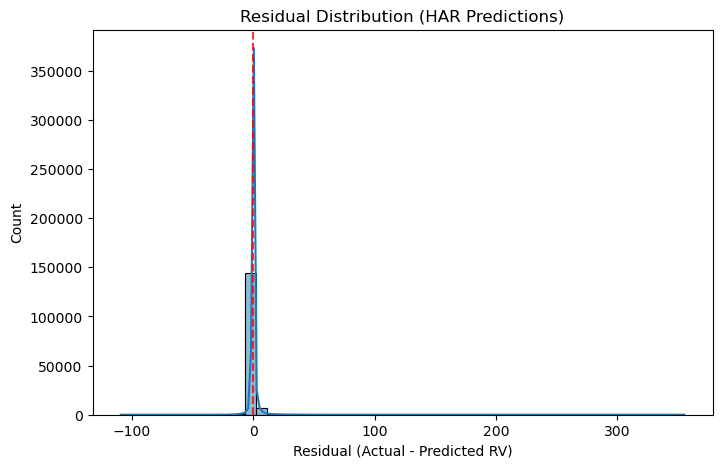

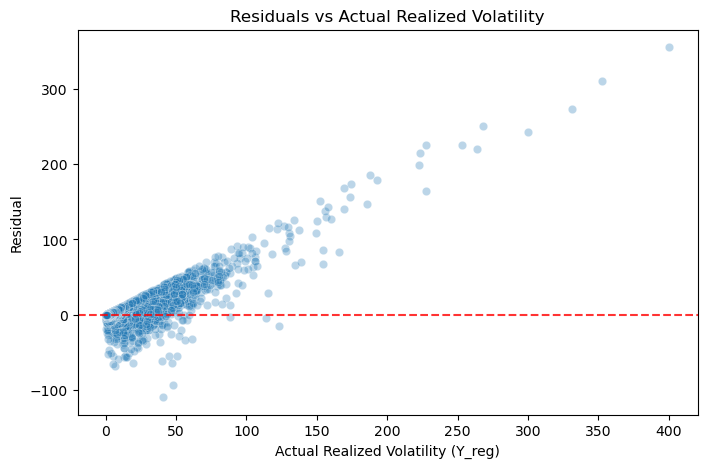

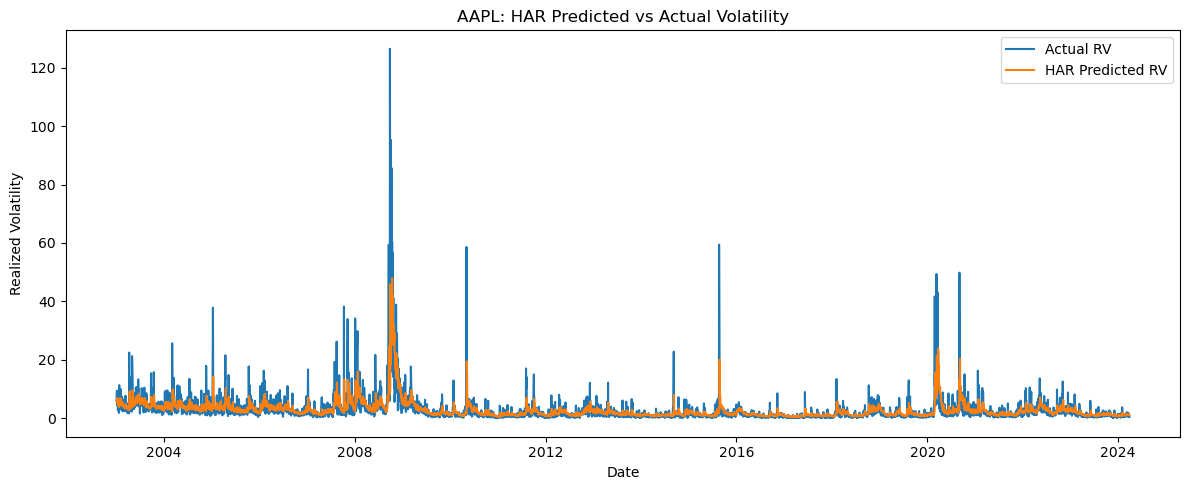

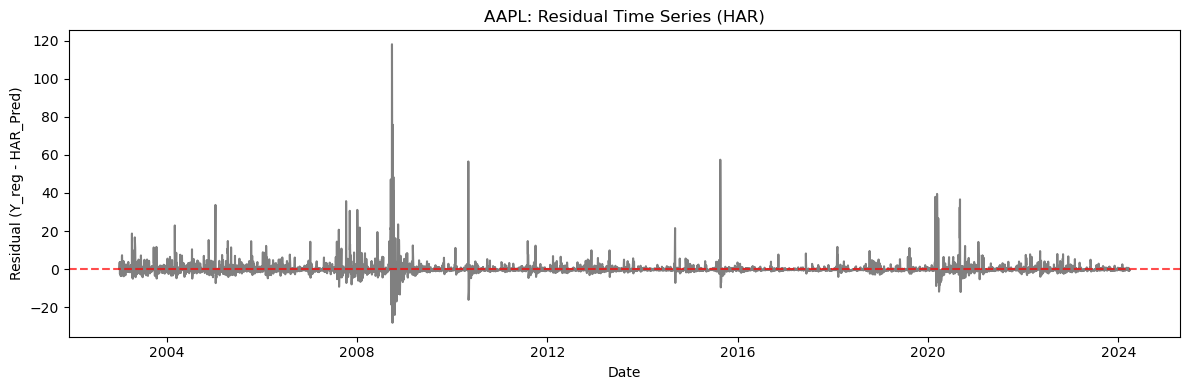

In [8]:
# HAR residual visualization
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8,5))
sns.histplot(df_full_har['residual'], bins=50, kde=True)
plt.title('Residual Distribution (HAR Predictions)')
plt.xlabel('Residual (Actual - Predicted RV)')
plt.ylabel('Count')
plt.axvline(0, color='red', linestyle='--', alpha=0.8)
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='Y_reg', y='residual', data=df_full_har, alpha=0.3)
plt.title('Residuals vs Actual Realized Volatility')
plt.xlabel('Actual Realized Volatility (Y_reg)')
plt.ylabel('Residual')
plt.axhline(0, color='red', linestyle='--', alpha=0.8)
plt.show()

sample_stock = 'AAPL'  
sample = df_full_har.xs(sample_stock, level='Stock')

plt.figure(figsize=(12,5))
plt.plot(sample.index, sample['Y_reg'], label='Actual RV', linewidth=1.5)
plt.plot(sample.index, sample['har_pred'], label='HAR Predicted RV', linewidth=1.5)
plt.title(f'{sample_stock}: HAR Predicted vs Actual Volatility')
plt.xlabel('Date')
plt.ylabel('Realized Volatility')
plt.legend()
plt.tight_layout()
plt.show()

# residual time series
plt.figure(figsize=(12,4))
plt.plot(sample.index, sample['residual'], label='Residuals', color='gray')
plt.axhline(0, color='red', linestyle='--', alpha=0.7)
plt.title(f'{sample_stock}: Residual Time Series (HAR)')
plt.xlabel('Date')
plt.ylabel('Residual (Y_reg - HAR_Pred)')
plt.tight_layout()
plt.show()


## Advanced ML Modeling (XGBoost)

In [9]:
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_squared_error, classification_report, confusion_matrix, precision_recall_fscore_support

all_features = (
    ['rv', 'bpv', 'good', 'bad'] +
    ['rq', 'vix', 'rv_lag_1', 'rv_rolling_5', 'rv_rolling_22'] +
    ['bpv_lag_1', 'good_lag_1', 'bad_lag_1', 'rq_lag_1', 'vix_lag_1'] +
    ['bad_good_ratio_lag_1', 'jump_ratio_lag_1']
)

df_ml = df_if.copy()
df_ml['Y_class_shifted'] = df_ml.groupby('Stock')['is_abnormal'].shift(-1)

df_reg = df_ml.dropna(subset=all_features + ['Y_reg']).copy().sort_index()
df_cls = df_ml.dropna(subset=all_features + ['Y_class_shifted']).copy().sort_index()

X_reg = df_reg[all_features]
y_reg = df_reg['Y_reg']

X_cls = df_cls[all_features]
y_cls = df_cls['Y_class_shifted'].astype(int)

split_date = pd.Timestamp('2020-01-01')
tscv_reg = TimeSeriesSplit(n_splits=N_SPLITS)
tscv_cls = TimeSeriesSplit(n_splits=N_SPLITS)


In [10]:
# Regression model (TimeSeriesSplit evaluation)
xgb_reg_params = dict(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_reg_mse_scores = []
df_reg['xgb_cv_pred'] = np.nan

print('\nTraining & Evaluation for XGBRegressor...')
for fold, (train_idx, test_idx) in enumerate(tscv_reg.split(X_reg), start=1):
    X_train_fold, X_test_fold = X_reg.iloc[train_idx], X_reg.iloc[test_idx]
    y_train_fold, y_test_fold = y_reg.iloc[train_idx], y_reg.iloc[test_idx]

    xgb_reg_fold = XGBRegressor(**xgb_reg_params)
    xgb_reg_fold.fit(X_train_fold, y_train_fold)

    y_pred_fold = xgb_reg_fold.predict(X_test_fold)
    mse_fold = mean_squared_error(y_test_fold, y_pred_fold)
    xgb_reg_mse_scores.append(mse_fold)

    df_reg.loc[X_test_fold.index, 'xgb_cv_pred'] = y_pred_fold

    print(f"  Fold {fold}: MSE = {mse_fold:.6f}")

average_xgb_reg_mse = float(np.mean(xgb_reg_mse_scores))
print(f"Average XGBRegressor MSE across {N_SPLITS} folds: {average_xgb_reg_mse:.6f}")



Training & Evaluation for XGBRegressor...
  Fold 1: MSE = 75.094055
  Fold 2: MSE = 2.342550
  Fold 3: MSE = 6.887066
  Fold 4: MSE = 20.525639
  Fold 5: MSE = 5.055963
Average XGBRegressor MSE across 5 folds: 21.981055


In [11]:
# XGB Classifier (TimeSeriesSplit evaluation)
xgb_cls_params = dict(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

y_true_all, y_pred_all = [], []
df_cls['xgb_cv_pred'] = np.nan

print('\nTraining & Evaluation for XGBClassifier...')
for fold, (train_idx, test_idx) in enumerate(tscv_cls.split(X_cls), start=1):
    X_train_fold, X_test_fold = X_cls.iloc[train_idx], X_cls.iloc[test_idx]
    y_train_fold, y_test_fold = y_cls.iloc[train_idx], y_cls.iloc[test_idx]

    xgb_cls_fold = XGBClassifier(**xgb_cls_params)
    xgb_cls_fold.fit(X_train_fold, y_train_fold)

    y_pred_fold = xgb_cls_fold.predict(X_test_fold)
    df_cls.loc[X_test_fold.index, 'xgb_cv_pred'] = y_pred_fold

    prec_fold, rec_fold, f1_fold, support_fold = precision_recall_fscore_support(
        y_test_fold, y_pred_fold, labels=[1], average=None, zero_division=0
    )
    print(f"  Fold {fold}: abnormal precision={prec_fold[0]:.4f}, recall={rec_fold[0]:.4f}, f1={f1_fold[0]:.4f}, support={support_fold[0]}")

    y_true_all.extend(y_test_fold)
    y_pred_all.extend(y_pred_fold)

print("\nXGBClassifier aggregated results:")
print(classification_report(y_true_all, y_pred_all, digits=4))
cm = confusion_matrix(y_true_all, y_pred_all)
print("Confusion Matrix:")
print(cm)


Training & Evaluation for XGBClassifier...
  Fold 1: abnormal precision=0.7051, recall=0.4901, f1=0.5783, support=6743
  Fold 2: abnormal precision=0.5534, recall=0.1782, f1=0.2696, support=1599
  Fold 3: abnormal precision=0.6815, recall=0.1279, f1=0.2153, support=1439
  Fold 4: abnormal precision=0.8084, recall=0.3601, f1=0.4982, support=3516
  Fold 5: abnormal precision=0.5381, recall=0.0879, f1=0.1511, support=2492

XGBClassifier aggregated results:
              precision    recall  f1-score   support

           0     0.9126    0.9805    0.9453    112111
           1     0.7064    0.3331    0.4527     15789

    accuracy                         0.9006    127900
   macro avg     0.8095    0.6568    0.6990    127900
weighted avg     0.8871    0.9006    0.8845    127900

Confusion Matrix:
[[109925   2186]
 [ 10530   5259]]


In [12]:
# Final holdout training for reporting & SHAP

dates_reg = df_reg.index.get_level_values('Date')
train_mask_reg = dates_reg < split_date
test_mask_reg = dates_reg >= split_date

X_train_reg_final, X_test_reg_final = X_reg.loc[train_mask_reg], X_reg.loc[test_mask_reg]
y_train_reg_final, y_test_reg_final = y_reg.loc[train_mask_reg], y_reg.loc[test_mask_reg]

xgb_reg_final = XGBRegressor(**xgb_reg_params)
xgb_reg_final.fit(X_train_reg_final, y_train_reg_final)

y_pred_reg_final = xgb_reg_final.predict(X_test_reg_final)
mse_xgb_holdout = mean_squared_error(y_test_reg_final, y_pred_reg_final)
print(f"\nHoldout XGBRegressor MSE (>= {split_date.date()}): {mse_xgb_holdout:.6f}")

df_reg.loc[X_test_reg_final.index, 'xgb_pred_holdout'] = y_pred_reg_final
df_reg['xgb_residual'] = df_reg['Y_reg'] - df_reg['xgb_pred_holdout']

har_holdout_mse = mean_squared_error(
    df_reg.loc[test_mask_reg, 'Y_reg'],
    df_reg.loc[test_mask_reg, 'har_pred']
)
print(f"Holdout HAR MSE (>= {split_date.date()}): {har_holdout_mse:.6f}")

# Classification final model
dates_cls = df_cls.index.get_level_values('Date')
train_mask_cls = dates_cls < split_date
test_mask_cls = dates_cls >= split_date

X_train_cls_final, X_test_cls_final = X_cls.loc[train_mask_cls], X_cls.loc[test_mask_cls]
y_train_cls_final, y_test_cls_final = y_cls.loc[train_mask_cls], y_cls.loc[test_mask_cls]

xgb_cls_final = XGBClassifier(**xgb_cls_params)
xgb_cls_final.fit(X_train_cls_final, y_train_cls_final)

y_pred_cls_final = xgb_cls_final.predict(X_test_cls_final)
print("\nHoldout Classification Report (XGBClassifier):")
print(classification_report(y_test_cls_final, y_pred_cls_final, digits=4))
cm_holdout = confusion_matrix(y_test_cls_final, y_pred_cls_final)
print("Confusion Matrix:")
print(cm_holdout)

df_cls.loc[X_test_cls_final.index, 'xgb_pred_holdout'] = y_pred_cls_final

# sync predictions back to master frame for inspection
df_ml.loc[df_reg.index, 'xgb_pred_holdout_reg'] = df_reg['xgb_pred_holdout']
df_ml.loc[df_cls.index, 'xgb_pred_holdout_cls'] = df_cls['xgb_pred_holdout']



Holdout XGBRegressor MSE (>= 2020-01-01): 20.112259
Holdout HAR MSE (>= 2020-01-01): 21.636397

Holdout Classification Report (XGBClassifier):
              precision    recall  f1-score   support

           0     0.8936    0.9881    0.9385     27370
           1     0.8063    0.2972    0.4343      4580

    accuracy                         0.8890     31950
   macro avg     0.8500    0.6426    0.6864     31950
weighted avg     0.8811    0.8890    0.8662     31950

Confusion Matrix:
[[27043   327]
 [ 3219  1361]]


C:\Users\lenovo\AppData\Local\Temp\ipykernel_23764\724184611.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['HAR','XGBoost'], y=[har_holdout_mse, mse_xgb_holdout], palette='coolwarm')


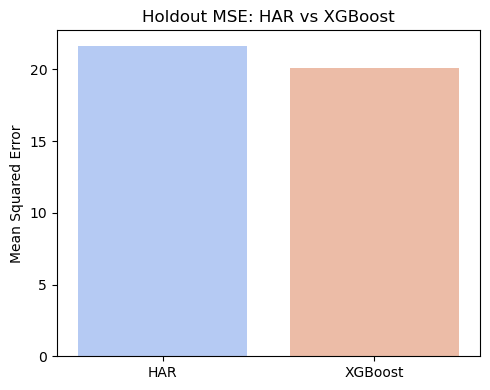

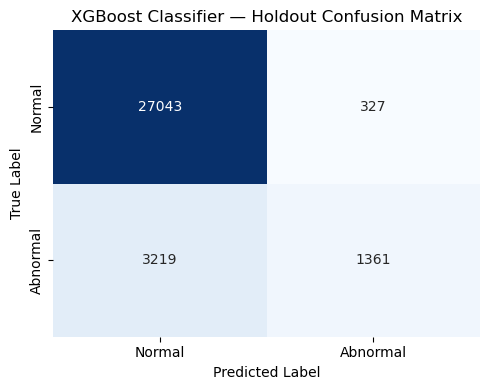


Example for AAPL — XGB Predictions:


,Y_reg,xgb_pred_holdout_reg,is_abnormal,Y_class_shifted,xgb_pred_holdout_cls
Date,,,,,
2024-03-21,1.216548,1.680717,0,0.0,0.0
2024-03-22,0.682342,1.316951,0,0.0,0.0
2024-03-25,0.425990,1.039303,0,0.0,0.0
2024-03-26,0.959378,0.839933,0,0.0,0.0
2024-03-27,0.563307,1.018262,0,NaN,NaN


In [14]:
# XGB visualization
plt.figure(figsize=(5,4))
sns.barplot(x=['HAR','XGBoost'], y=[har_holdout_mse, mse_xgb_holdout], palette='coolwarm')
plt.ylabel('Mean Squared Error')
plt.title('Holdout MSE: HAR vs XGBoost')
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
sns.heatmap(cm_holdout, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal','Abnormal'], yticklabels=['Normal','Abnormal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('XGBoost Classifier — Holdout Confusion Matrix')
plt.tight_layout()
plt.show()

sample_stock = df_ml.index.get_level_values('Stock')[0]
sample = df_ml.xs(sample_stock, level='Stock').tail()
print(f"\nExample for {sample_stock} — XGB Predictions:")
display(sample[['Y_reg','xgb_pred_holdout_reg','is_abnormal','Y_class_shifted','xgb_pred_holdout_cls']])